# Computer Vision 1: Assignment 3

Task 2

Group Number 43

Marek Drwal

15.12.2025

## setup

In [18]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

## defs

In [19]:
def show_img(img, pth='', comment=''):
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment +' ' + pth)
    plt.show()

In [20]:
def load_display_img(pth, is_gray=False):
    img = ski.io.imread(pth)
    if not is_gray:
        show_img(img, pth, 'org')
        img = ski.color.rgb2gray(img)
    show_img(img, pth, 'gray')
    return img

In [21]:
def augment_img(img, pth='', display=True, noise_smooth=True):
    if noise_smooth:
        N = ski.util.random_noise(img, 'gaussian', var=0.01, rng=123)
        show_img(N, pth, 'noise')
        S = ski.filters.gaussian(N, sigma=1)
        show_img(S, pth, 'smooth')
        FN = ski.filters.sobel(N)
        show_img(FN, pth, 'Sobel on noise')
        FS = ski.filters.sobel(S)
        show_img(FS, pth, 'Sobel on smooth')
        return N, S, FN, FS
    FS = ski.filters.sobel(img)
    show_img(FS, pth, 'Sobel on')
    return FS

In [22]:
def plot_img_hist(img, no_bins=500):
    return plt.hist(img.ravel(), bins=no_bins, range=(0,1), histtype='step')

In [23]:
def binary_mask(img, threshold, pth='', name=''):
    masked_img = np.where(img.ravel() > threshold, True, False).reshape(img.shape)
    show_img(masked_img, pth, f'{name} masked with {threshold}')
    return masked_img

## imgs

In [24]:
pth = 'yellow_horizon.jpg'

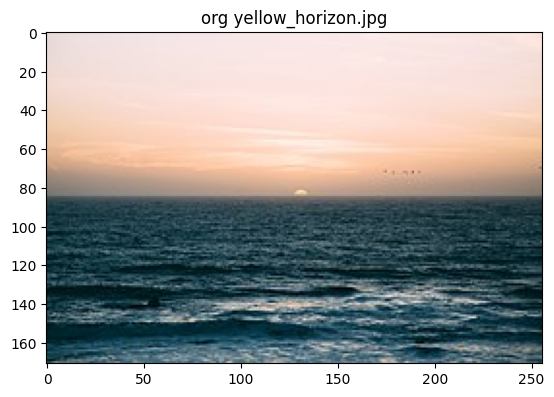

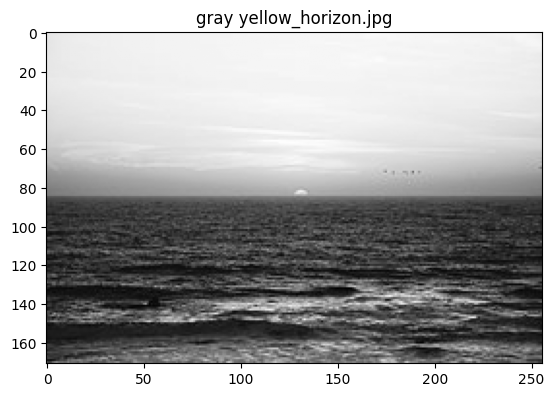

In [25]:
img = load_display_img(pth)

## Sobel

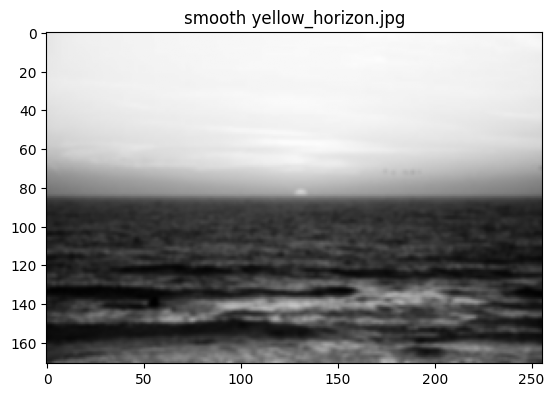

In [26]:
smooth_img = ski.filters.gaussian(img)
show_img(smooth_img, pth, 'smooth')

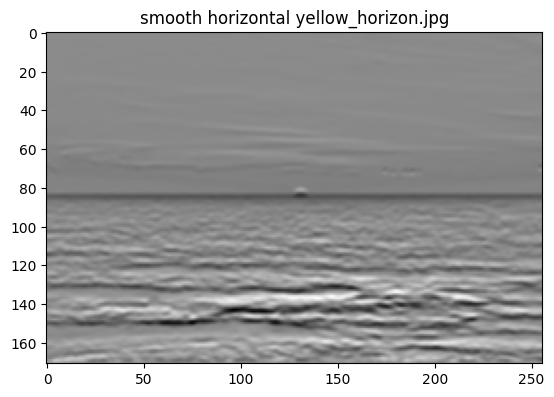

In [27]:
h_img = ski.filters.sobel_h(smooth_img)
show_img(h_img, pth, 'smooth horizontal')

## candidate pts

In [110]:
fpt = np.zeros_like(img)

In [111]:
x = 0

In [112]:
fpt[:, x] = 1 # vert

In [113]:
img.shape

(171, 256)

In [114]:
img

array([[0.85452118, 0.85452118, 0.85844275, ..., 0.90766627, 0.90374471,
        0.89982314],
       [0.85844275, 0.85844275, 0.86236431, ..., 0.90374471, 0.89982314,
        0.89982314],
       [0.86236431, 0.86236431, 0.86628588, ..., 0.90374471, 0.89982314,
        0.89590157],
       ...,
       [0.23616078, 0.2596902 , 0.24343843, ..., 0.3417149 , 0.3540451 ,
        0.4238    ],
       [0.09490902, 0.0671149 , 0.04578   , ..., 0.18485216, 0.16132275,
        0.20053843],
       [0.31059529, 0.23832549, 0.26380431, ..., 0.31337804, 0.2310251 ,
        0.23494667]])

In [115]:
fpt[0].shape

(256,)

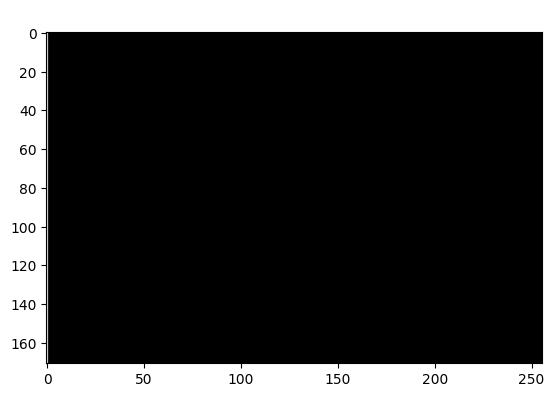

In [116]:
show_img(fpt)

In [117]:
fpt

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [118]:
fpt.shape

(171, 256)

In [119]:
ski.filters.rank.gradient(h_img, fpt).shape

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\interactiveshell.py:3667: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  exec(code_obj, self.user_global_ns, self.user_ns)


(171, 256)

In [120]:
ski.filters.rank.gradient(h_img, fpt)

array([[ 0,  0,  0, ...,  7,  7,  7],
       [ 0,  0,  0, ...,  7,  7,  7],
       [ 0,  0,  0, ...,  7,  7,  7],
       ...,
       [ 0,  0,  0, ..., 74, 78, 79],
       [ 0,  0,  0, ..., 74, 78, 79],
       [ 0,  0,  0, ..., 74, 78, 79]], dtype=uint8)

In [121]:
np.argmin(ski.filters.rank.gradient(h_img, fpt))

np.int64(0)

In [122]:
np.argmin(ski.filters.rank.gradient(h_img, fpt), axis=1)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [123]:
np.min(ski.filters.rank.gradient(h_img, fpt))

np.uint8(0)

In [124]:
np.argmin(ski.filters.rank.gradient(h_img, fpt, mask=fpt))

np.int64(0)

In [125]:
ski.filters.rank.gradient(h_img, fpt, mask=fpt)[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8)

### min grad

In [152]:
pts = np.zeros_like(img)
xs = []
ys = []

for x in range(0, img.shape[1]-1, img.shape[1] // 20): # horiz col
    fpt = np.zeros_like(img)
    fpt[:, x] = 1 # vert
    # print(fpt)
    # show_img(fpt)
    y = np.argmin(ski.filters.rank.gradient(h_img, fpt), axis=1) # vert row , mask=fpt
    print(y, x)
    xs.append(x)
    ys.append(y)
    # pts[y, x] = 1

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] 0
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] 12
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

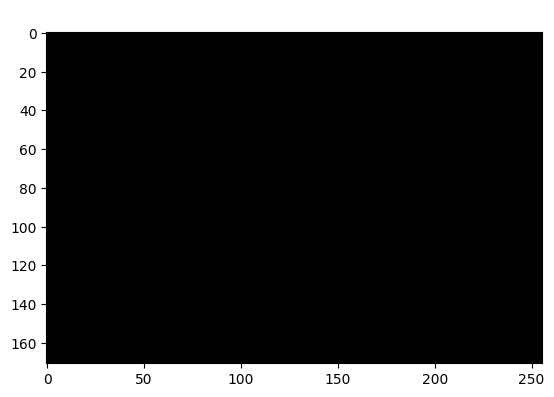

In [146]:
show_img(pts)

### min h

In [128]:
pts = np.zeros_like(img)
xs = []
ys = []

for x in range(0, img.shape[1]-1, img.shape[1] // 20): # horiz col
    fpt = np.zeros_like(img)
    fpt[:, x] = 1 # vert
    # print(fpt)
    # show_img(fpt)
    y = np.argmin(h_img[:, x]) # vert row
    print(y, x)
    xs.append(x)
    ys.append(y)
    # pts[y, x] = 1

115 0
85 12
150 24
85 36
131 48
150 60
150 72
149 84
143 96
144 108
150 120
133 132
131 144
132 156
151 168
151 180
141 192
151 204
140 216
85 228
147 240
147 252


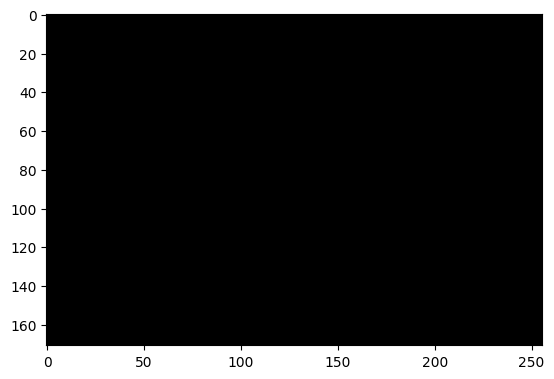

In [129]:
plt.imshow(pts, cmap=plt.cm.gray, )

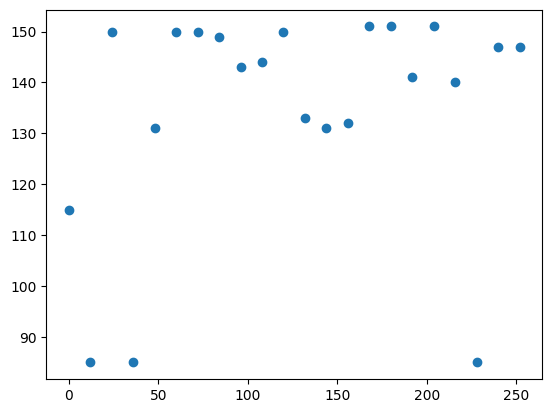

In [ ]:
p = plt.scatter(xs, ys)
p.set

### min grads

In [166]:
pts = np.zeros_like(img)
xs = []
ys = []
fpt = np.ones_like(img[0])
fpt = ski.morphology.footprint_rectangle((img.shape[0], 1))
ys = np.argmin(ski.filters.rank.gradient(h_img, fpt), axis=0) # vert row , mask=fpt
xs = [x for x in range(0, img.shape[1]-1, img.shape[1] // 20)]

# for x in range(0, img.shape[1]-1, img.shape[1] // 20): # horiz col
#     fpt = np.ones_like(img[0])
#     # fpt[:, x] = 1 # vert
#     # print(fpt)
#     # show_img(fpt)
    
#     print(y, x)
#     xs.append(x)
#     ys.append(y)
#     # pts[y, x] = 1

In [167]:
xs

[0,
 12,
 24,
 36,
 48,
 60,
 72,
 84,
 96,
 108,
 120,
 132,
 144,
 156,
 168,
 180,
 192,
 204,
 216,
 228,
 240,
 252]

In [168]:
ys

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

ValueError: x and y must have same first dimension, but have shapes (22,) and (256,)

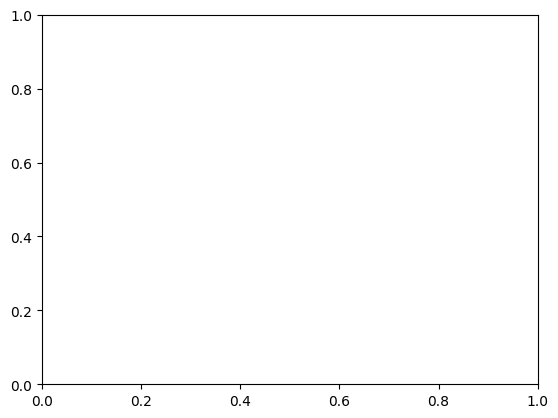

In [169]:
plt.plot(xs, ys, 'bo')
plt.xlim(0,img.shape[1])
plt.ylim(0,img.shape[0])

### gemini

In [178]:
grad_A = np.gradient(h_img, axis=0)
grad_A

array([[ 2.72257822e-03,  2.82712890e-03,  2.98277174e-03, ...,
         1.73902462e-04,  1.73277050e-04,  7.14674713e-05],
       [ 6.50561238e-04,  6.35958781e-04,  5.13944064e-04, ...,
         2.18477027e-03,  2.21736786e-03,  2.07946866e-03],
       [-2.38425188e-03, -2.52154062e-03, -2.86942496e-03, ...,
         4.52579148e-03,  4.74951808e-03,  4.83887121e-03],
       ...,
       [ 2.37148083e-02,  2.90755458e-02,  4.40430014e-02, ...,
        -2.27419465e-02, -4.11362687e-02, -5.63704446e-02],
       [ 3.40935361e-02,  3.59617150e-02,  3.86136471e-02, ...,
         3.97992866e-02,  3.84851220e-02,  3.60326457e-02],
       [ 9.92660493e-03,  9.59707259e-03,  4.40203772e-04, ...,
         5.18511819e-02,  6.49356068e-02,  7.43448472e-02]])

In [179]:
min_gradient_row_indices = np.argmin(grad_A, axis=0)
min_gradient_row_indices

array([113, 113, 113, 149, 149, 149, 129, 129, 129, 129, 170, 170, 170,
       170, 170, 113, 113, 113, 149, 149, 130, 146, 146, 146, 168, 129,
       129, 145, 145, 168, 144, 144, 130, 130, 130, 146, 144, 144, 145,
       145, 145, 144, 144, 144, 130, 130, 130, 130, 119, 119, 148, 119,
       149, 149, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148, 148,
       148, 148, 148, 148, 148, 149, 131, 131, 148, 148, 148, 148, 148,
       148, 147, 147, 119, 119, 119, 139, 139, 139, 139, 140, 140, 140,
       141, 141, 142, 142, 142, 142, 142, 142, 141, 141, 141, 141, 147,
       147, 148, 148, 148, 148, 148, 148, 142, 142, 143, 143, 143, 148,
       148, 148, 148, 148, 132, 132, 132, 132, 132, 141, 141, 149, 149,
       141,  83, 148, 148, 148, 140, 140, 140, 147, 147, 147, 147, 147,
       130, 130, 130, 130, 130, 130, 130, 130, 130, 148, 148, 148, 130,
       130, 131, 131, 162, 162, 140, 141, 141, 140, 140, 140, 140, 149,
       149, 149, 149, 149, 149, 140, 140, 140, 135, 135, 135, 13

In [180]:
min_gradient_row_indices.shape

(256,)

In [181]:
pts = np.zeros_like(img)
xs = []
ys = []

for x in range(0, img.shape[1]-1, img.shape[1] // 20): # horiz col
    y = min_gradient_row_indices[x]
    pts[y,x] = 1
    print(y, x)
    xs.append(x)
    ys.append(y)

113 0
170 12
168 24
144 36
119 48
148 60
131 72
139 84
142 96
148 108
148 120
148 132
130 144
130 156
149 168
135 180
161 192
162 204
138 216
163 228
145 240
146 252


(0.0, 171.0)

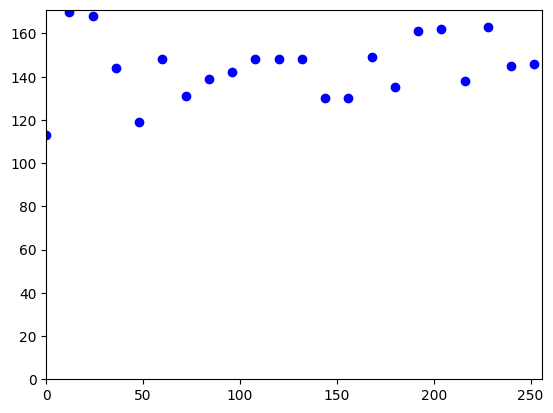

In [182]:
plt.plot(xs, ys, 'bo')
plt.xlim(0,img.shape[1])
plt.ylim(0,img.shape[0])

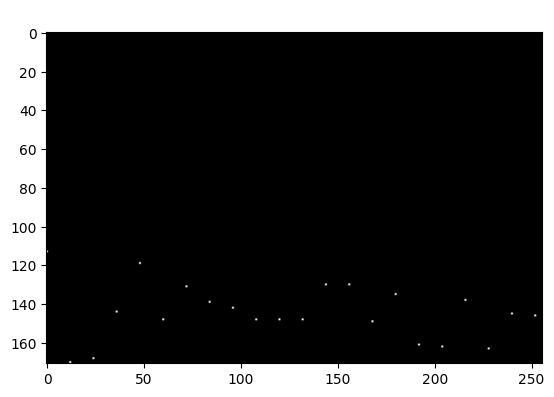

In [183]:
show_img(pts)

## RANSAC

In [ ]:
rr = RANSACRegressor()
rr

In [ ]:
# rr.fit()